# Modeling — Classification (Iteration 4)

Reframes the forecasting problem as multi-class classification: instead of predicting exact kWh,
we predict the **demand level** (Idle / Low / Medium / High) for each station-hour.

**Motivation:** With R² = 0.514 on regression, exact load prediction is difficult due to the
event-driven nature of EV charging. A grid operator may not need exact kWh — knowing whether
a station will be idle vs. under heavy load is often enough for scheduling and DR decisions.

**Input:** `data/processed/ev_features.parquet`  
**Output:** `results/iteration_4/classification_comparison.csv`, `results/iteration_4/best_classifier.pkl`

### Class Definitions
| Class | Load Range | Interpretation |
|-------|-----------|----------------|
| **Idle** (0) | < 0.1 kWh | No meaningful charging activity |
| **Low** (1) | 0.1 – 5 kWh | Light usage (trickle / single vehicle) |
| **Medium** (2) | 5 – 20 kWh | Moderate usage |
| **High** (3) | ≥ 20 kWh | Heavy usage (multiple vehicles / fast charging) |

### Models
| # | Model | Type |
|---|-------|------|
| 1 | Majority class | Naive baseline |
| 2 | LightGBM (default) | Gradient boosting |
| 3 | XGBoost (default) | Gradient boosting |
| 4 | LightGBM (tuned) | Optuna-tuned |
| 5 | XGBoost (tuned) | Optuna-tuned |

## 0. Setup & Load

In [1]:
import warnings
import gc
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')

# Find project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'ev_features.parquet'
RESULTS_DIR   = PROJECT_ROOT / 'results' / 'iteration_4'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project


/Users/alemz/micromamba/envs/pyclass/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(FEATURES_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# --- Define demand level classes ---
# Thresholds chosen from training-set distribution analysis:
#   Idle  (<0.1):  ~56% — station not meaningfully active
#   Low   (0.1–5): ~26% — light single-vehicle charging
#   Medium(5–20):  ~14% — moderate usage
#   High  (≥20):   ~4%  — heavy / multi-vehicle usage

CLASS_BINS   = [0, 0.1, 5, 20, float('inf')]
CLASS_LABELS = ['Idle', 'Low', 'Medium', 'High']
CLASS_MAP    = {label: i for i, label in enumerate(CLASS_LABELS)}

df['demand_level'] = pd.cut(
    df['target'], bins=CLASS_BINS, labels=CLASS_LABELS, right=False
).cat.codes.astype('int8')  # 0=Idle, 1=Low, 2=Medium, 3=High

print(f'\nClass distribution (full dataset):')
counts = df['demand_level'].value_counts().sort_index()
for i, label in enumerate(CLASS_LABELS):
    print(f'  {i} ({label:6s}): {counts[i]:>10,} ({counts[i]/len(df)*100:5.1f}%)')

# --- Train/test split ---
SPLIT_DATE = pd.Timestamp('2022-07-01')

train = df[df['timestamp_hour'] < SPLIT_DATE].copy()
test  = df[df['timestamp_hour'] >= SPLIT_DATE].copy()

print(f'\nTrain: {len(train):,} rows  |  Test: {len(test):,} rows')

# --- Define feature columns ---
EXCLUDE = ['customer_id', 'timestamp_hour', 'target', 'year', 'demand_level']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS]
y_train = train['demand_level']
X_test  = test[FEATURE_COLS]
y_test  = test['demand_level']

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# --- Class distribution in train vs test ---
print(f'\nTrain class distribution:')
for i, label in enumerate(CLASS_LABELS):
    n = (y_train == i).sum()
    print(f'  {label:6s}: {n:>10,} ({n/len(y_train)*100:5.1f}%)')
print(f'\nTest class distribution:')
for i, label in enumerate(CLASS_LABELS):
    n = (y_test == i).sum()
    print(f'  {label:6s}: {n:>10,} ({n/len(y_test)*100:5.1f}%)')

del df
gc.collect()

Loaded: 7,229,089 rows × 40 cols

Class distribution (full dataset):
  0 (Idle  ):  4,076,788 ( 56.4%)
  1 (Low   ):  1,830,711 ( 25.3%)
  2 (Medium):    996,651 ( 13.8%)
  3 (High  ):    324,939 (  4.5%)

Train: 4,712,026 rows  |  Test: 2,517,063 rows
Features (36): ['is_weekend', 'is_holiday', 'temperature_c', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'cloud_cover_pct', 'is_raining', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_roll_mean_6h', 'load_roll_std_6h', 'load_roll_mean_12h', 'load_roll_std_12h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_7d', 'load_roll_std_7d', 'load_lag_168h', 'load_change_1h', 'load_ratio_24h', 'hour_x_weekend', 'is_cold', 'city_code', 'public_private_code', 'business_type_code', 'contract_power_kw_norm', 'total_quantity_norm']

Train class distribution:
  Idle  :  2,643,469 ( 56.1%)
  Low   :  1,221,614 ( 25.9%)
  Medium:    645,082 (

20

## 1. Evaluation Framework

In [3]:
results = []

def evaluate_classifier(name, y_true, y_pred):
    """Compute classification metrics and append to results list."""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_per_class = f1_score(y_true, y_pred, average=None)

    row = {
        'Model': name,
        'Accuracy': acc,
        'F1 (macro)': f1_macro,
        'F1 (weighted)': f1_weighted,
    }
    for i, label in enumerate(CLASS_LABELS):
        row[f'F1 ({label})'] = f1_per_class[i] if i < len(f1_per_class) else 0.0

    results.append(row)
    print(f'{name:<30} Acc={acc:.4f}  F1(macro)={f1_macro:.4f}  F1(weighted)={f1_weighted:.4f}')
    return row


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot confusion matrix with percentages."""
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS).plot(ax=axes[0], cmap='Blues')
    axes[0].set_title(f'{title} — Counts')

    # Normalized (recall per class)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_LABELS).plot(
        ax=axes[1], cmap='Blues', values_format='.2f'
    )
    axes[1].set_title(f'{title} — Recall (normalized by row)')

    plt.tight_layout()
    plt.show()


print('Evaluation framework ready.')

Evaluation framework ready.


## 2. Naive Baseline — Majority Class

In [4]:
# Predict the most common class (Idle) for everything
majority_class = y_train.mode()[0]
print(f'Majority class: {CLASS_LABELS[majority_class]} ({majority_class})')

y_pred_majority = np.full(len(y_test), majority_class)
evaluate_classifier('Majority Class', y_test, y_pred_majority)

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_majority, target_names=CLASS_LABELS, zero_division=0))

Majority class: Idle (0)
Majority Class                 Acc=0.5694  F1(macro)=0.1814  F1(weighted)=0.4132

Classification Report:
              precision    recall  f1-score   support

        Idle       0.57      1.00      0.73   1433319
         Low       0.00      0.00      0.00    609097
      Medium       0.00      0.00      0.00    351569
        High       0.00      0.00      0.00    123078

    accuracy                           0.57   2517063
   macro avg       0.14      0.25      0.18   2517063
weighted avg       0.32      0.57      0.41   2517063



## 3. Default Classifiers

Class weights: {'Idle': np.float64(0.46), 'Low': np.float64(0.94), 'Medium': np.float64(1.75), 'High': np.float64(5.88)}
Best iteration: 389
LightGBM (default)             Acc=0.8064  F1(macro)=0.6671  F1(weighted)=0.7986


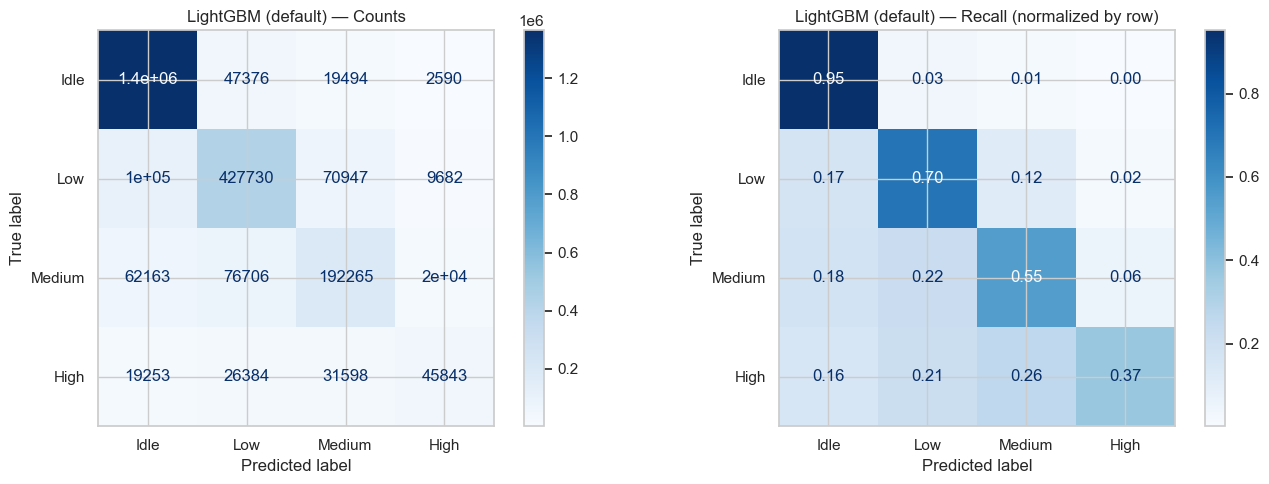

10451

In [5]:
# --- LightGBM (default) ---
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

# Compute class weights from training data
class_counts = np.bincount(y_tr, minlength=4)
class_weights = len(y_tr) / (4 * class_counts)
sample_weight_train = np.array([class_weights[c] for c in y_tr])

print(f'Class weights: {dict(zip(CLASS_LABELS, class_weights.round(2)))}')

lgbm_clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    num_class=4,
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True,
)

lgbm_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {lgbm_clf.best_iteration_}')

y_pred_lgbm = lgbm_clf.predict(X_test)
evaluate_classifier('LightGBM (default)', y_test, y_pred_lgbm)
plot_confusion_matrix(y_test, y_pred_lgbm, 'LightGBM (default)')

del X_tr, X_val, y_tr, y_val, sample_weight_train
gc.collect()

Best iteration: 498
XGBoost (default)              Acc=0.7610  F1(macro)=0.6318  F1(weighted)=0.7754


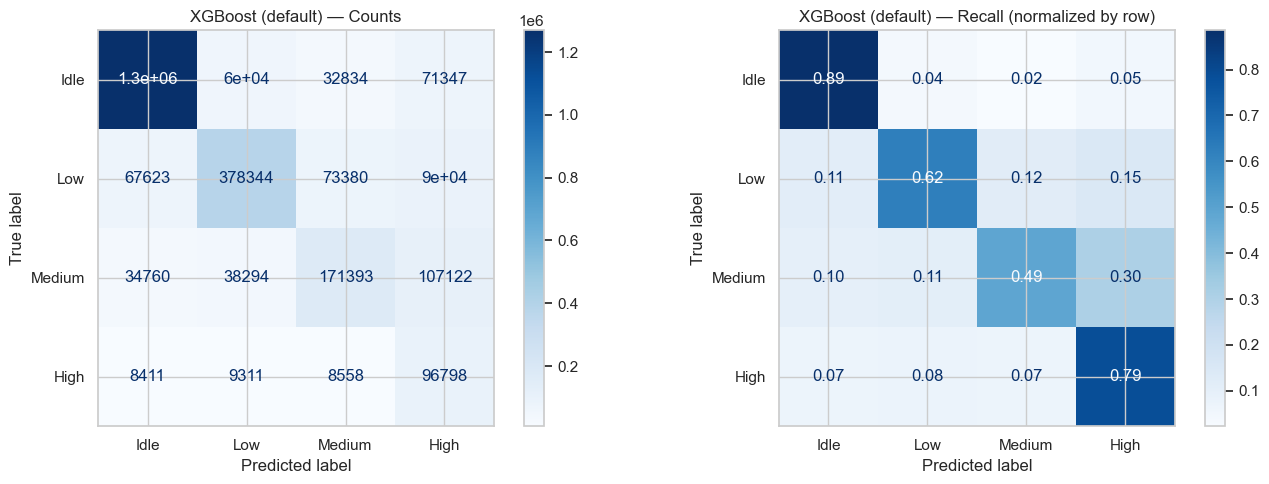

10941

In [6]:
# --- XGBoost (default) ---
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

# Compute sample weights for XGBoost (doesn't have is_unbalance)
class_counts = np.bincount(y_tr, minlength=4)
class_weights = len(y_tr) / (4 * class_counts)
sample_weight_train = np.array([class_weights[c] for c in y_tr])
sample_weight_val   = np.array([class_weights[c] for c in y_val])

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=4,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',
)

xgb_clf.fit(
    X_tr, y_tr,
    sample_weight=sample_weight_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sample_weight_val],
    verbose=False,
)

print(f'Best iteration: {xgb_clf.best_iteration}')

y_pred_xgb = xgb_clf.predict(X_test)
evaluate_classifier('XGBoost (default)', y_test, y_pred_xgb)
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost (default)')

del X_tr, X_val, y_tr, y_val, sample_weight_train, sample_weight_val
gc.collect()

## 4. Optuna Tuning

Same strategy as regression (notebook 06): 50% subsample, 30 trials per model.

In [7]:
# --- Subsample for tuning ---
TUNE_FRAC = 0.5
tune_idx = np.random.RandomState(42).choice(len(X_train), int(len(X_train) * TUNE_FRAC), replace=False)
tune_idx.sort()
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

# Validation split (last 10%)
tune_split = int(len(X_tune) * 0.9)
X_tune_tr, X_tune_val = X_tune.iloc[:tune_split], X_tune.iloc[tune_split:]
y_tune_tr, y_tune_val = y_tune.iloc[:tune_split], y_tune.iloc[tune_split:]

print(f'Tuning subset: {len(X_tune):,} rows ({TUNE_FRAC*100:.0f}% of train)')
print(f'  Train: {len(X_tune_tr):,}  Val: {len(X_tune_val):,}')

Tuning subset: 2,356,013 rows (50% of train)
  Train: 2,120,411  Val: 235,602


In [8]:
def lgbm_clf_objective(trial):
    params = {
        'n_estimators': 500,
        'objective': 'multiclass',
        'num_class': 4,
        'is_unbalance': True,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 128),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tune_tr, y_tune_tr,
        eval_set=[(X_tune_val, y_tune_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )

    preds = model.predict(X_tune_val)
    # Optimize macro F1 — gives equal weight to all classes including minority
    return f1_score(y_tune_val, preds, average='macro')


print('Tuning LightGBM classifier (30 trials on 50% subsample)...')
lgbm_clf_study = optuna.create_study(direction='maximize', study_name='lgbm_clf')
lgbm_clf_study.optimize(lgbm_clf_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest F1 (macro): {lgbm_clf_study.best_value:.4f}')
print(f'Best params: {lgbm_clf_study.best_params}')

Tuning LightGBM classifier (30 trials on 50% subsample)...


Best trial: 15. Best value: 0.58846: 100%|██████████| 30/30 [45:46<00:00, 91.54s/it] 


Best F1 (macro): 0.5885
Best params: {'learning_rate': 0.06089898669223723, 'num_leaves': 111, 'max_depth': 9, 'min_child_samples': 61, 'subsample': 0.6040252529230743, 'colsample_bytree': 0.704844774755781, 'reg_alpha': 7.732306293528966e-06, 'reg_lambda': 0.5258282000671064}


Best iteration: 279
LightGBM (tuned)               Acc=0.8082  F1(macro)=0.6697  F1(weighted)=0.8004


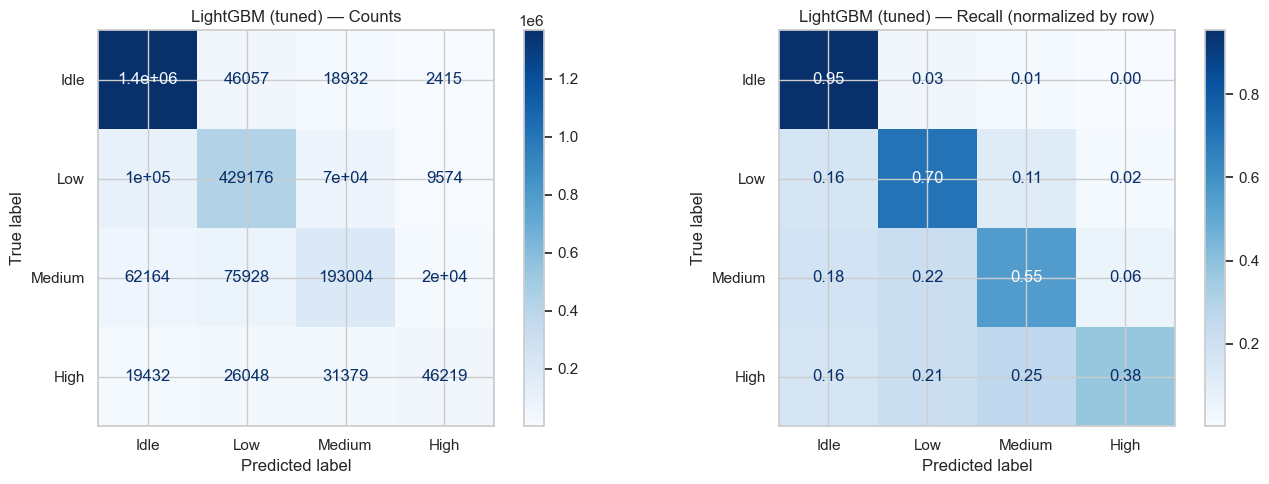


Classification Report:
              precision    recall  f1-score   support

        Idle       0.88      0.95      0.92   1433319
         Low       0.74      0.70      0.72    609097
      Medium       0.62      0.55      0.58    351569
        High       0.59      0.38      0.46    123078

    accuracy                           0.81   2517063
   macro avg       0.71      0.65      0.67   2517063
weighted avg       0.80      0.81      0.80   2517063



10590

In [9]:
# Retrain with best params on full training set
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

best_lgbm_clf_params = {
    'n_estimators': 1000,
    'objective': 'multiclass',
    'num_class': 4,
    'is_unbalance': True,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    **lgbm_clf_study.best_params,
}

lgbm_tuned_clf = lgb.LGBMClassifier(**best_lgbm_clf_params)
lgbm_tuned_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {lgbm_tuned_clf.best_iteration_}')

y_pred_lgbm_tuned = lgbm_tuned_clf.predict(X_test)
evaluate_classifier('LightGBM (tuned)', y_test, y_pred_lgbm_tuned)
plot_confusion_matrix(y_test, y_pred_lgbm_tuned, 'LightGBM (tuned)')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lgbm_tuned, target_names=CLASS_LABELS))

del X_tr, X_val, y_tr, y_val
gc.collect()

In [10]:
def xgb_clf_objective(trial):
    params = {
        'n_estimators': 500,
        'objective': 'multi:softmax',
        'num_class': 4,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'early_stopping_rounds': 30,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'tree_method': 'hist',
    }

    # Compute sample weights for class imbalance
    class_counts = np.bincount(y_tune_tr, minlength=4)
    class_weights = len(y_tune_tr) / (4 * class_counts)
    sw_tr  = np.array([class_weights[c] for c in y_tune_tr])
    sw_val = np.array([class_weights[c] for c in y_tune_val])

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_tune_tr, y_tune_tr,
        sample_weight=sw_tr,
        eval_set=[(X_tune_val, y_tune_val)],
        sample_weight_eval_set=[sw_val],
        verbose=False,
    )

    preds = model.predict(X_tune_val)
    return f1_score(y_tune_val, preds, average='macro')


print('Tuning XGBoost classifier (30 trials on 50% subsample)...')
xgb_clf_study = optuna.create_study(direction='maximize', study_name='xgb_clf')
xgb_clf_study.optimize(xgb_clf_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest F1 (macro): {xgb_clf_study.best_value:.4f}')
print(f'Best params: {xgb_clf_study.best_params}')

Tuning XGBoost classifier (30 trials on 50% subsample)...


Best trial: 6. Best value: 0.570606: 100%|██████████| 30/30 [1:07:24<00:00, 134.80s/it]


Best F1 (macro): 0.5706
Best params: {'learning_rate': 0.054330714047245515, 'max_depth': 12, 'min_child_weight': 1, 'subsample': 0.7776466864418583, 'colsample_bytree': 0.6454614123430746, 'reg_alpha': 0.6605217857353423, 'reg_lambda': 2.000827193245282e-05}


Best iteration: 135
XGBoost (tuned)                Acc=0.7698  F1(macro)=0.6405  F1(weighted)=0.7817


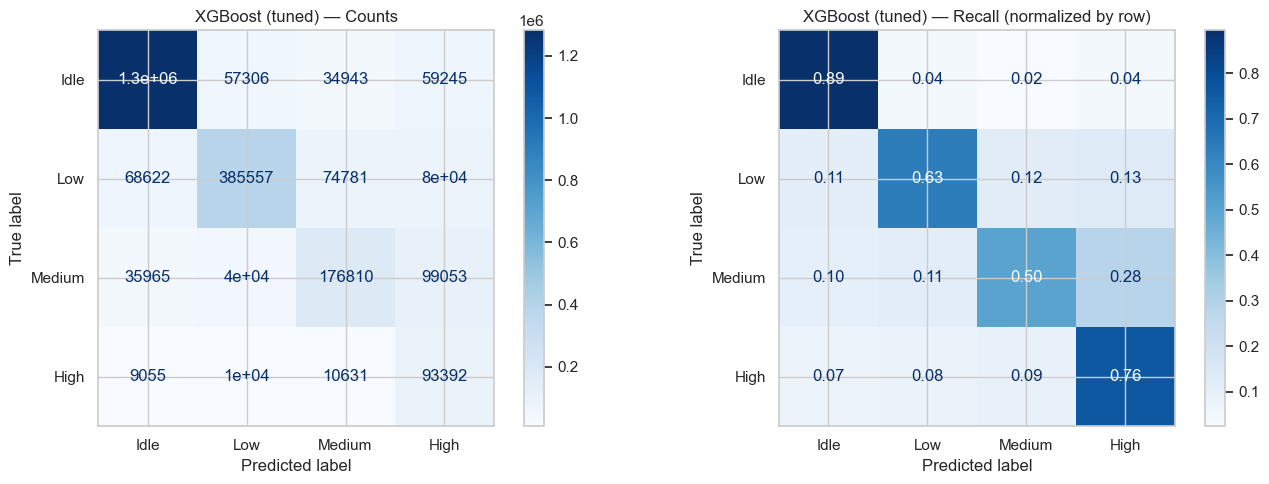


Classification Report:
              precision    recall  f1-score   support

        Idle       0.92      0.89      0.91   1433319
         Low       0.78      0.63      0.70    609097
      Medium       0.59      0.50      0.55    351569
        High       0.28      0.76      0.41    123078

    accuracy                           0.77   2517063
   macro avg       0.64      0.70      0.64   2517063
weighted avg       0.81      0.77      0.78   2517063



10977

In [11]:
# Retrain with best params on full training set
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

class_counts = np.bincount(y_tr, minlength=4)
class_weights = len(y_tr) / (4 * class_counts)
sw_tr  = np.array([class_weights[c] for c in y_tr])
sw_val = np.array([class_weights[c] for c in y_val])

best_xgb_clf_params = {
    'n_estimators': 1000,
    'objective': 'multi:softmax',
    'num_class': 4,
    'early_stopping_rounds': 50,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
    'tree_method': 'hist',
    **xgb_clf_study.best_params,
}

xgb_tuned_clf = xgb.XGBClassifier(**best_xgb_clf_params)
xgb_tuned_clf.fit(
    X_tr, y_tr,
    sample_weight=sw_tr,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[sw_val],
    verbose=False,
)

print(f'Best iteration: {xgb_tuned_clf.best_iteration}')

y_pred_xgb_tuned = xgb_tuned_clf.predict(X_test)
evaluate_classifier('XGBoost (tuned)', y_test, y_pred_xgb_tuned)
plot_confusion_matrix(y_test, y_pred_xgb_tuned, 'XGBoost (tuned)')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb_tuned, target_names=CLASS_LABELS))

del X_tr, X_val, y_tr, y_val, sw_tr, sw_val
gc.collect()

## 5. Overfitting Check

In [12]:
overfit_rows = []

for name, model in [('LightGBM (tuned)', lgbm_tuned_clf), ('XGBoost (tuned)', xgb_tuned_clf)]:
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_tr)
    test_acc  = accuracy_score(y_test, y_pred_te)
    train_f1  = f1_score(y_train, y_pred_tr, average='macro')
    test_f1   = f1_score(y_test, y_pred_te, average='macro')

    overfit_rows.append({
        'Model': name,
        'Train Acc': train_acc, 'Test Acc': test_acc, 'Acc Gap': train_acc - test_acc,
        'Train F1': train_f1, 'Test F1': test_f1, 'F1 Gap': train_f1 - test_f1,
    })

overfit_df = pd.DataFrame(overfit_rows)
print('=== Overfitting Check ===')
print(overfit_df.to_string(index=False))

for _, row in overfit_df.iterrows():
    gap = row['F1 Gap']
    if gap < 0.03:
        verdict = 'No overfitting'
    elif gap < 0.07:
        verdict = 'Mild overfitting'
    else:
        verdict = 'Overfitting detected'
    print(f"\n{row['Model']}: F1 gap = {gap:.4f} → {verdict}")

=== Overfitting Check ===
           Model  Train Acc  Test Acc   Acc Gap  Train F1  Test F1    F1 Gap
LightGBM (tuned)   0.802174  0.808209 -0.006035  0.660856 0.669665 -0.008809
 XGBoost (tuned)   0.778108  0.769780  0.008328  0.656425 0.640474  0.015951

LightGBM (tuned): F1 gap = -0.0088 → No overfitting

XGBoost (tuned): F1 gap = 0.0160 → No overfitting


## 6. Final Comparison

=== Classification Model Comparison ===
             Model  Accuracy  F1 (macro)  F1 (weighted)  F1 (Idle)  F1 (Low)  F1 (Medium)  F1 (High)
    Majority Class  0.569441    0.181415       0.413221   0.725661  0.000000     0.000000   0.000000
LightGBM (default)  0.806375    0.667068       0.798599   0.915547  0.720513     0.577482   0.454729
 XGBoost (default)  0.760991    0.631799       0.775389   0.902175  0.690877     0.537506   0.396636
  LightGBM (tuned)  0.808209    0.669665       0.800393   0.916345  0.723550     0.580605   0.458160
   XGBoost (tuned)  0.769780    0.640474       0.781655   0.906272  0.699930     0.545092   0.410600


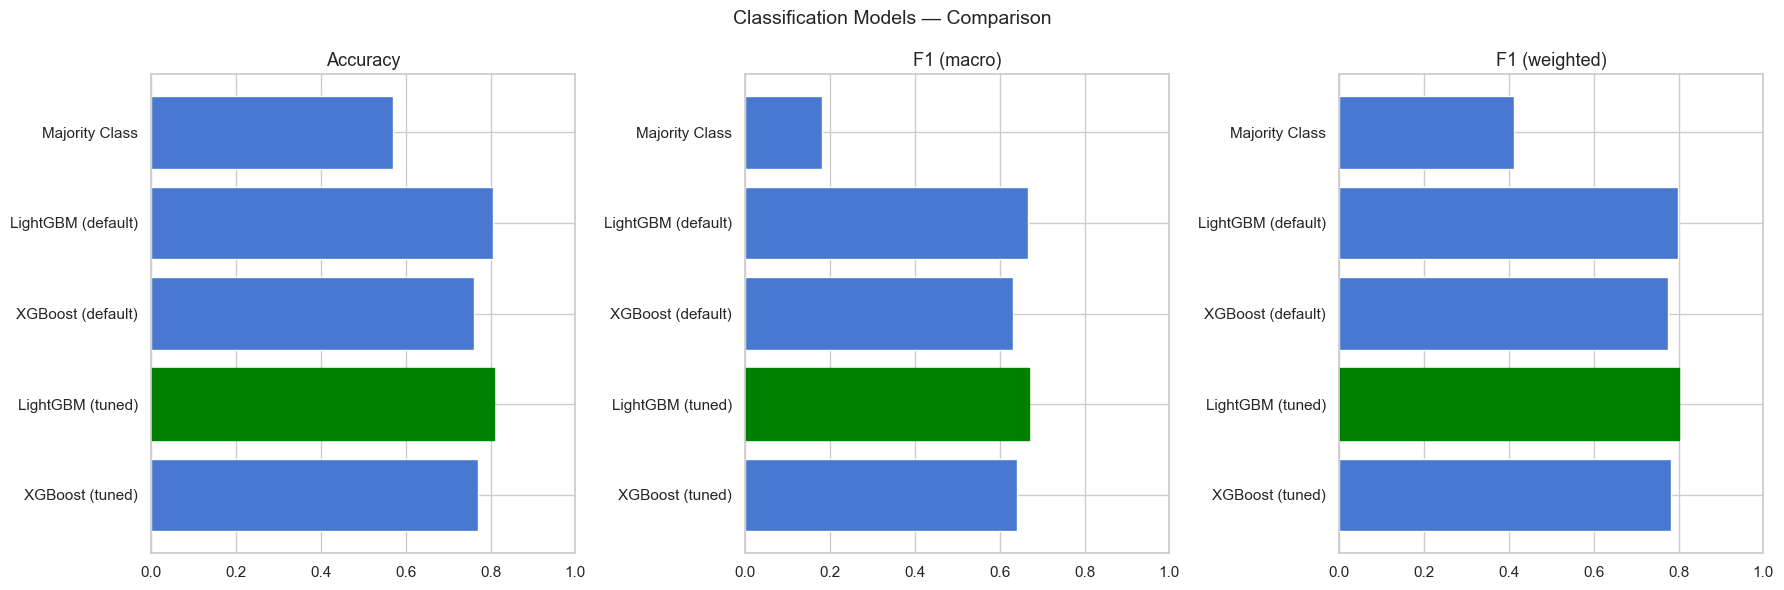

In [13]:
results_df = pd.DataFrame(results)
print('=== Classification Model Comparison ===')
print(results_df.to_string(index=False))

# --- Bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(['Accuracy', 'F1 (macro)', 'F1 (weighted)']):
    bars = axes[i].barh(results_df['Model'], results_df[metric])
    axes[i].set_title(metric, fontsize=13)
    axes[i].invert_yaxis()
    axes[i].set_xlim(0, 1)

    best_idx = results_df[metric].idxmax()
    bars[best_idx].set_color('green')

plt.suptitle('Classification Models — Comparison', fontsize=14)
plt.tight_layout()
plt.show()

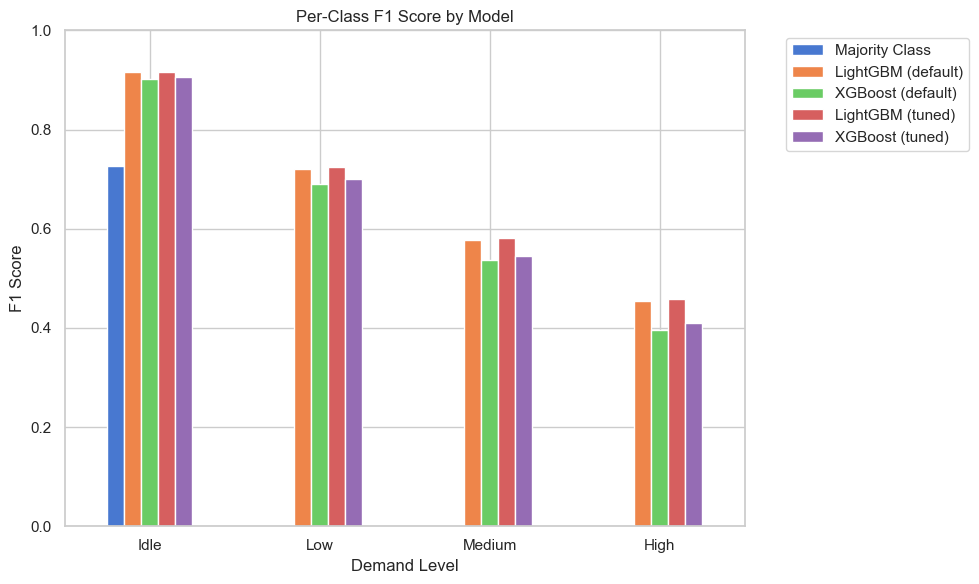

                      Idle     Low  Medium    High
Model                                             
Majority Class      0.7257  0.0000  0.0000  0.0000
LightGBM (default)  0.9155  0.7205  0.5775  0.4547
XGBoost (default)   0.9022  0.6909  0.5375  0.3966
LightGBM (tuned)    0.9163  0.7236  0.5806  0.4582
XGBoost (tuned)     0.9063  0.6999  0.5451  0.4106


In [14]:
# --- Per-class F1 comparison ---
f1_cols = [f'F1 ({label})' for label in CLASS_LABELS]
f1_data = results_df[['Model'] + f1_cols].set_index('Model')
f1_data.columns = CLASS_LABELS

fig, ax = plt.subplots(figsize=(10, 6))
f1_data.T.plot(kind='bar', ax=ax)
ax.set_ylabel('F1 Score')
ax.set_xlabel('Demand Level')
ax.set_title('Per-Class F1 Score by Model')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f1_data.round(4).to_string())

## 7. Feature Importance

Best model: LightGBM (tuned)


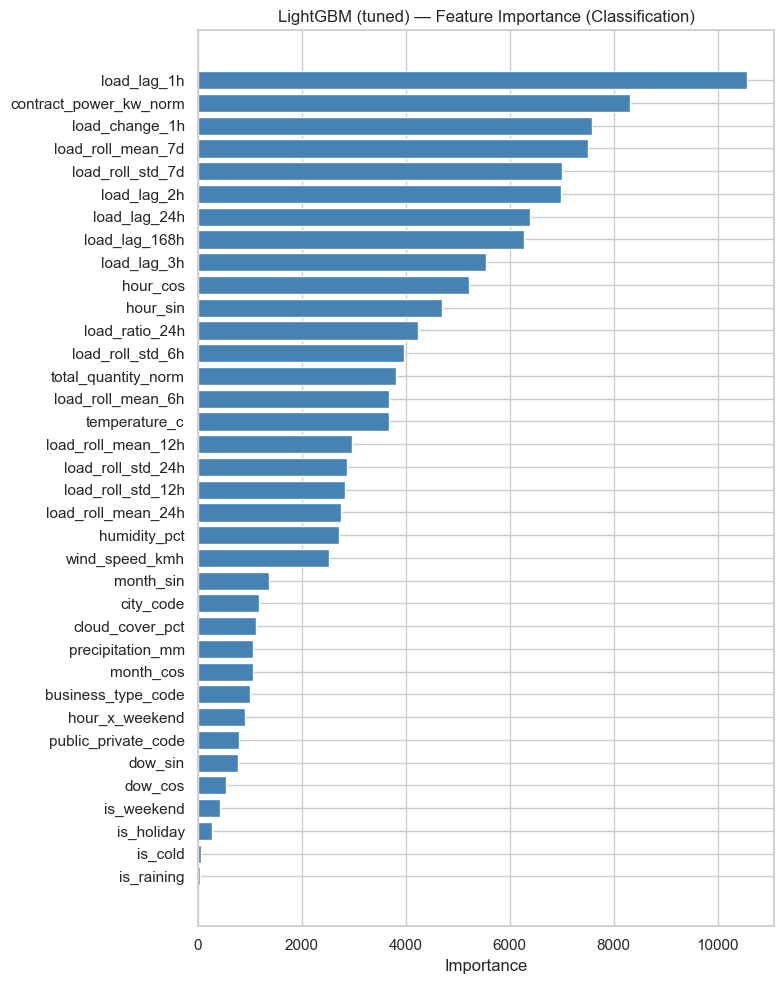


Top 15 features:
               feature  importance  pct
           load_lag_1h       10556 11.5
contract_power_kw_norm        8311  9.1
        load_change_1h        7575  8.3
     load_roll_mean_7d        7508  8.2
      load_roll_std_7d        7010  7.6
           load_lag_2h        6994  7.6
          load_lag_24h        6380  7.0
         load_lag_168h        6274  6.8
           load_lag_3h        5550  6.0
              hour_cos        5206  5.7
              hour_sin        4702  5.1
        load_ratio_24h        4235  4.6
      load_roll_std_6h        3969  4.3
   total_quantity_norm        3806  4.1
     load_roll_mean_6h        3676  4.0


In [15]:
# Use best model's feature importance
best_name = results_df.loc[results_df['F1 (macro)'].idxmax(), 'Model']
print(f'Best model: {best_name}')

if 'LightGBM' in best_name:
    importances = lgbm_tuned_clf.feature_importances_
else:
    importances = xgb_tuned_clf.feature_importances_

importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_title(f'{best_name} — Feature Importance (Classification)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Top 15
top15 = importance.tail(15).sort_values('importance', ascending=False)
top15['pct'] = (top15['importance'] / top15['importance'].sum() * 100).round(1)
print(f'\nTop 15 features:')
print(top15[['feature', 'importance', 'pct']].to_string(index=False))

## 8. Classification vs Regression — Comparison

How does the classification approach compare to the regression model from iteration 3?

In [16]:
# Load regression results for comparison
reg_path = PROJECT_ROOT / 'results' / 'iteration_3' / 'model_comparison.csv'
if reg_path.exists():
    reg_results = pd.read_csv(reg_path)
    print('=== Regression (Iteration 3) — Best Results ===')
    best_reg = reg_results.loc[reg_results['R²'].idxmax()]
    print(f"  Model: {best_reg['Model']}")
    print(f"  R²:    {best_reg['R²']:.4f}")
    print(f"  MAE:   {best_reg['MAE']:.4f} kWh")
    print(f"  RMSE:  {best_reg['RMSE']:.4f} kWh")
    print()

    # Convert regression predictions to classes and compare
    # Load the best regression model and make predictions
    reg_model_path = PROJECT_ROOT / 'results' / 'iteration_3' / 'best_model.pkl'
    if reg_model_path.exists():
        reg_model = joblib.load(reg_model_path)
        y_pred_reg = np.clip(reg_model.predict(X_test), 0, None)

        # Bin regression predictions into classes
        y_pred_reg_classes = np.digitize(y_pred_reg, bins=[0.1, 5, 20]) 
        # digitize returns 0 for <0.1, 1 for 0.1-5, 2 for 5-20, 3 for >=20

        reg_acc = accuracy_score(y_test, y_pred_reg_classes)
        reg_f1_macro = f1_score(y_test, y_pred_reg_classes, average='macro')
        reg_f1_weighted = f1_score(y_test, y_pred_reg_classes, average='weighted')

        print('=== Regression → Classification (binned predictions) ===')
        print(f'  Accuracy:     {reg_acc:.4f}')
        print(f'  F1 (macro):   {reg_f1_macro:.4f}')
        print(f'  F1 (weighted):{reg_f1_weighted:.4f}')
        print()

        # Compare side-by-side
        best_clf = results_df.loc[results_df['F1 (macro)'].idxmax()]
        print('=== Head-to-Head ===')
        print(f'{"Metric":<20} {"Regression (binned)":>20} {"Classification":>20}')
        print(f'{"Accuracy":<20} {reg_acc:>20.4f} {best_clf["Accuracy"]:>20.4f}')
        print(f'{"F1 (macro)":<20} {reg_f1_macro:>20.4f} {best_clf["F1 (macro)"]:>20.4f}')
        print(f'{"F1 (weighted)":<20} {reg_f1_weighted:>20.4f} {best_clf["F1 (weighted)"]:>20.4f}')

        del reg_model
        gc.collect()
    else:
        print('Regression model not found — skipping direct comparison.')
else:
    print('Regression results not found — run notebook 06 first.')

=== Regression (Iteration 3) — Best Results ===
  Model: XGBoost (tuned)
  R²:    0.5138
  MAE:   2.7578 kWh
  RMSE:  5.9818 kWh

=== Regression → Classification (binned predictions) ===
  Accuracy:     0.4229
  F1 (macro):   0.4396
  F1 (weighted):0.4130

=== Head-to-Head ===
Metric                Regression (binned)       Classification
Accuracy                           0.4229               0.8082
F1 (macro)                         0.4396               0.6697
F1 (weighted)                      0.4130               0.8004


## 9. Save Results

In [17]:
# Save comparison table
results_df.to_csv(RESULTS_DIR / 'classification_comparison.csv', index=False)
print(f'Saved comparison → {RESULTS_DIR / "classification_comparison.csv"}')

# Save best classifier
best_name = results_df.loc[results_df['F1 (macro)'].idxmax(), 'Model']
best_model_map = {
    'LightGBM (default)': lgbm_clf,
    'XGBoost (default)': xgb_clf,
    'LightGBM (tuned)': lgbm_tuned_clf,
    'XGBoost (tuned)': xgb_tuned_clf,
}

if best_name in best_model_map:
    model_path = RESULTS_DIR / 'best_classifier.pkl'
    joblib.dump(best_model_map[best_name], model_path)
    print(f'Saved best model ({best_name}) → {model_path}')

# Save Optuna studies
joblib.dump(lgbm_clf_study, RESULTS_DIR / 'optuna_lgbm_clf_study.pkl')
joblib.dump(xgb_clf_study, RESULTS_DIR / 'optuna_xgb_clf_study.pkl')
print(f'Saved Optuna studies → {RESULTS_DIR}')

# Save feature importance
importance.sort_values('importance', ascending=False).head(15).to_csv(
    RESULTS_DIR / 'feature_importance_top15.csv', index=False
)
print(f'Saved feature importance → {RESULTS_DIR / "feature_importance_top15.csv"}')

print('\nDone. Classification iteration complete.')

Saved comparison → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_4/classification_comparison.csv
Saved best model (LightGBM (tuned)) → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_4/best_classifier.pkl
Saved Optuna studies → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_4
Saved feature importance → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_4/feature_importance_top15.csv

Done. Classification iteration complete.


## Key Takeaways

**Why classification?**  
The regression model (R² = 0.514) struggles to predict exact hourly kWh because EV charging is
event-driven — a car either plugs in or doesn't. Classification reframes this as a more practical
question: *will this station be idle, lightly used, moderately busy, or under heavy load?*

**Class imbalance:**  
~56% of station-hours are idle (< 0.1 kWh). We handle this with `is_unbalance=True` (LightGBM)
and explicit sample weights (XGBoost), and optimize for macro F1 to give equal weight to minority classes.

**Practical value:**  
A grid operator scheduling demand response doesn't need to know that a station will draw 14.7 kWh
— they need to know it will be in the "Medium" load tier. This matches how DR programs typically
set participation thresholds.